In [1]:
#packages
from pyspark.sql import SparkSession, DataFrame
import pyspark.sql.dataframe
import pyspark.sql.functions as f
from pyspark.sql.functions import col
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, Imputer
import math as m
from pyspark.ml.stat import Correlation
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Create a spark session (which will run spark jobs)
spark = (
    SparkSession.builder.appName("Project 1")
    .config("spark.sql.repl.eagerEval.enabled", True) 
    .config("spark.sql.parquet.cacheMetadata", "true")
    .config("spark.sql.session.timeZone", "Etc/UTC")
    .getOrCreate()
)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
25/09/24 15:28:32 WARN Utils: Your hostname, Lachys-Laptop, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
25/09/24 15:28:32 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/09/24 15:28:33 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/09/24 15:28:35 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


In [3]:
#reading in data\n

tbl_merchants_raw = spark.read.parquet('../data/tables/merchant_data/tbl_merchants.parquet')
consumer_user_details = spark.read.parquet('../data/tables/merchant_data/consumer_user_details.parquet')
transactions21 = spark.read.parquet('../data/tables/transaction_data/transactions_20210228_20210827_snapshot/')
transactions2122 = spark.read.parquet('../data/tables/transaction_data/transactions_20210828_20220227_snapshot/')
transactions22 = spark.read.parquet('../data/tables/transaction_data/transactions_20220228_20220828_snapshot/')
con_fraud_prob = spark.read.option("header","true").csv('../data/tables/merchant_data/consumer_fraud_probability.csv')
merch_fraud_prob = spark.read.option("header", "true").csv('../data/tables/merchant_data/merchant_fraud_probability.csv')

tbl_consumer_raw = spark.read.option("header", "true").csv('../data/tables/merchant_data/tbl_consumer.csv')

transactions = transactions21.unionByName(transactions2122)
transactions = transactions.unionByName(transactions22)

In [4]:
#Functions
def OHE_variables(data, cat_nom_columns, cat_ord_columns):
    
    """Indexes and encodes categorical features"""

    for c in cat_nom_columns:
        indexer = StringIndexer(inputCol=c, outputCol=str(c) + '_index')
        
        indexed_df = indexer.fit(data).transform(data)
        data.drop(c)
        encoder = OneHotEncoder(inputCol=str(c)+'_index', outputCol=str(c)+'_OHE')
        encoded_df = encoder.fit(indexed_df).transform(indexed_df)
        data.drop(str(c)+'_index')

    for c in cat_ord_columns:
        indexer = StringIndexer(inputCol=c, outputCol=str(c) + '_index')
        indexed_df = indexer.fit(data).transform(data)
        data.drop(c)
        
    return data

def find_NULL(dfs):
    for df in dfs:
        condition = f.lit(False)
        for col_name in df.columns:
            condition = condition | f.col(col_name).isNull()

        df.filter(condition).show()
    return df.filter(condition).count()

def filter_outliers(data, variables):
    
    """filters outliers of continuous data"""

    n=data.count()
    for feature in variables:
        # Calculate Q1 and Q3
        quantiles = data.approxQuantile(feature, [0.25, 0.75], 0.01)
        q1, q3 = quantiles
        iqr = q3 - q1

        #from ADS lecture slides, n>>100
        scale = m.sqrt(m.log(n)) - 0.5
        if scale<3:
            scale=3
        lower_bound = q1 - scale * iqr
        upper_bound = q3 + scale * iqr
        if lower_bound<0:
            data = data.filter((col(feature) >= 0) & (col(feature) <= upper_bound))
        else:
            data = data.filter((col(feature) >= lower_bound) & (col(feature) <= upper_bound))
    
    return data

def corr_func(data, CORR_COLS):

    """A function to return the correlation matrix of correlation between variables"""

    features = "correlation_features"

    assembler = VectorAssembler(
        inputCols=CORR_COLS, 
        outputCol=features 
    )
    
    feature_vector = assembler.transform(data).select(features)

    corr_matrix_dense = Correlation.corr(feature_vector, features)
    corr_matrix_dense.collect()
    corr_matrix = corr_matrix_dense.collect()[0][0].toArray().tolist()

    return corr_matrix

def spark_shape(self):
        return (self.count(), len(self.columns))
pyspark.sql.dataframe.DataFrame.shape = property(spark_shape)

In [5]:
#cleaning tags
string = "name|address|state|postcode|gender|consumer_id"

# Clean consumer table
tbl_consumer = (
    tbl_consumer_raw
    .withColumn("cust_name", f.split(col(string), "\\|").getItem(0))
    .withColumn("address", f.split(col(string), "\\|").getItem(1))
    .withColumn("state", f.split(col(string), "\\|").getItem(2))
    .withColumn("postcode", f.split(col(string), "\\|").getItem(3))
    .withColumn("gender", f.split(col(string), "\\|").getItem(4))
    .withColumn("consumer_id", f.split(col(string), "\\|").getItem(5))
    .drop(string)
)


# Clean merchants table
tbl_merchants = (
    tbl_merchants_raw
    # remove leading (( or [[ and trailing )) or ]]
    .withColumn(
        "tags_clean",
        f.regexp_replace(
            "tags",
            r"^\(\(|^\(\[|^\[\(|^\[\[|\)\)$|\]\)$|\)\]$|\]\]$",
            ""
        )
    )
    # split on `), (` or `], [`
    .withColumn("tags_array", f.split("tags_clean", r"\)\s*,\s*\(|\]\s*,\s*\["))
    # extract each element
    .withColumn("biz_tags", f.lower(f.col("tags_array")[0]))
    .withColumn("rev_band", f.col("tags_array")[1])
    .withColumn("take_rate", f.regexp_extract(f.col("tags_array")[2], r"take rate:\s*([0-9.]+)", 1)
    )
    .drop("tags", "tags_clean", "tags_array")
)

tbl_merchants=tbl_merchants.withColumn("biz_tags", f.regexp_replace("biz_tags", "  ", " "))

In [6]:
merchant_transactions=transactions.join(tbl_merchants, on='merchant_abn', how='left')
#find_NULL([merchant_transactions])

In [7]:
merchant_transactions = merchant_transactions.dropna()

In [4]:
#merchant_transactions.groupBy('name').count().orderBy("count", ascending=True).show()

In [8]:
#filter outliers by biz_tag

n = merchant_transactions.count()
# compute the scale factor
scale = m.sqrt(m.log(n)) - 0.5
stats_by_band = (merchant_transactions.groupby('biz_tags')
                                      .agg(f.expr("percentile_approx(dollar_value, 0.25)").alias("Q1"),
                                           f.expr("percentile_approx(dollar_value, 0.75)").alias("Q3")
                ).withColumn("IQR", f.col("Q3") - f.col("Q1"))
                 .withColumn("lower_bound", f.col("Q1") - scale * f.col("IQR"))
                 .withColumn("upper_bound", f.col("Q3") + scale * f.col("IQR"))
                )
stats_by_band = stats_by_band.drop('IQR')

In [9]:
print(merchant_transactions.shape)

(13614675, 9)


In [10]:
merchant_transactions = (
    merchant_transactions
    .join(stats_by_band, on="biz_tags", how="left")
    .filter(
        (col("dollar_value") >= col('lower_bound')) &
        (col("dollar_value") <= col("upper_bound"))
    )
    .select(merchant_transactions["*"])
)

In [11]:
print(merchant_transactions.shape)

(13293844, 9)


In [ ]:
merchant_transactions=merchant_transactions.withColumnRenamed('name', 'business')
merchant_transactions=merchant_transactions.drop('order_id',)

In [13]:
merchant_transactions

merchant_abn,user_id,dollar_value,order_datetime,business,biz_tags,rev_band,take_rate
15549624934,2,130.3505283105634,2021-08-20,Commodo Associates,"opticians, optica...",c,2.76
46804135891,18482,6.6168976971833615,2021-08-20,Suspendisse Dui C...,"opticians, optica...",c,2.93
11237511112,15,86.43306925925785,2021-08-20,Magna Institute,"opticians, optica...",c,2.11
48534649627,37,115.71011998439714,2021-08-20,Dignissim Maecena...,"opticians, optica...",a,6.64
22059270846,18563,13.552320313774313,2021-08-20,Montes Nascetur R...,"opticians, optica...",a,6.59
46804135891,83,40.88736687931136,2021-08-20,Suspendisse Dui C...,"opticians, optica...",c,2.93
81410315303,90,97.01139408070111,2021-08-20,Sed Dictum PC,"opticians, optica...",a,6.35
46804135891,96,71.58993600692456,2021-08-20,Suspendisse Dui C...,"opticians, optica...",c,2.93
60602272553,112,17.429130408212,2021-08-20,Sagittis Duis Gra...,"opticians, optica...",b,4.93
46804135891,118,14.417591756971596,2021-08-20,Suspendisse Dui C...,"opticians, optica...",c,2.93


In [16]:
merchant_transactions.groupBy("biz_tags").agg(
    f.min("dollar_value").alias("min_value"),
    f.max("dollar_value").alias("max_value"),
    f.mean("dollar_value").alias("mean"),
    (f.max("dollar_value") - f.min("dollar_value")).alias("range")
).orderBy("mean", ascending=False).show()

+--------------------+--------------------+------------------+------------------+------------------+
|            biz_tags|           min_value|         max_value|              mean|             range|
+--------------------+--------------------+------------------+------------------+------------------+
|jewelry, watch, c...|   3.409793978681009| 46001.13901942742|  9278.56318565421| 45997.72922544874|
|art dealers and g...|  0.4127496907944707| 10335.94618503865| 1966.235783927586|10335.533435347856|
|             telecom|  0.2931526313090789| 11606.18761084434|1735.6703991984089| 11605.89445821303|
|equipment, tool, ...|0.040595292090802974| 8813.127778854296| 1261.652706482709| 8813.087183562206|
|stationery, offic...|0.004010169952587961| 2333.490127589658|456.97980173991294| 2333.486117419706|
|health and beauty...| 6.59812930332817E-4|1672.2945523725923| 294.9553375878973| 1672.293892559662|
|motor vehicle sup...|7.092782606876731E-4|1356.3937038188778| 271.4403187831411| 1356.3929

In [17]:
tbl_consumer=tbl_consumer.drop('address', 'cust_name', 'gender')
#tbl_consumer

In [ ]:
#merch_tran_cust=merchant_transactions.join(consumer_user_details, on='user_id', how='left')
#merch_tran_cust=merch_tran_cust.join(tbl_consumer, on='consumer_id', how='left')
#merch_tran_cust=merch_tran_cust.drop('consumer_id', 'order_id')

In [18]:
mtc_fraud1=merchant_transactions.join(merch_fraud_prob, on=['merchant_abn', 'order_datetime'], how='left')
mtc_fraud1=mtc_fraud1.withColumnRenamed('fraud_probability', 'merch_fraud_prob')
mtc_fraud=mtc_fraud1.join(con_fraud_prob, on=['user_id', 'order_datetime'], how='left')
mtc_fraud=mtc_fraud.withColumnRenamed('fraud_probability', 'con_fraud_prob')

In [15]:
#mtc_fraud

In [16]:
curated=mtc_fraud.groupBy(['merchant_abn', 'user_id']).agg(
    f.count('*').alias('count'),
    f.mean('dollar_value').alias('mean'),
    f.mean('merch_fraud_prob').alias('merch_fraud_prob'),
    f.mean('con_fraud_prob').alias('con_fraud_prob')
)



In [17]:
#curated

In [18]:
new_curated=curated.join(consumer_user_details, on='user_id', how='left')
new_curated=new_curated.join(tbl_consumer, on='consumer_id', how='left')
new_curated=new_curated.drop('consumer_id')

In [19]:
#new_curated

In [20]:
print(new_curated.shape)

(7881927, 8)


In [5]:
#new_curated.write.parquet("data/curated/agg_by_userbiz", mode="overwrite")

In [15]:
merchant_transactions.write.parquet("../data/curated/merchant_transactions", mode="overwrite")

[1013.481s][warning][gc,alloc] Executor task launch worker for task 4.0 in stage 52.0 (TID 964): Retried waiting for GCLocker too often allocating 23781 words


[704.231s][warning][gc,alloc] Executor task launch worker for task 6.0 in stage 177.0 (TID 1291): Retried waiting for GCLocker too often allocating 31001 words


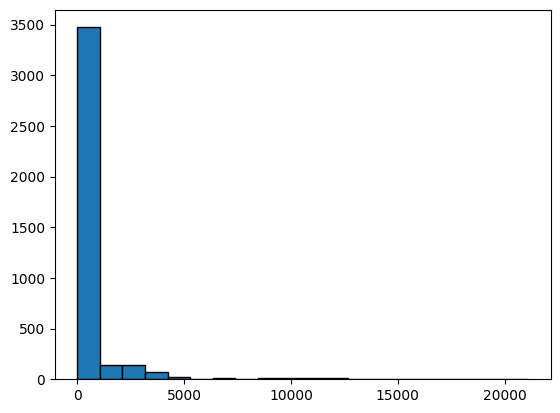

In [25]:
dollar_vals=mtc_fraud.select("mean")

bin_edges, counts = (
    dollar_vals
    .rdd.flatMap(lambda x: x)     # flatten column
    .histogram(20)                # 20 bins
)

# Plot
plt.bar(
    bin_edges[:-1], counts,
    width=[bin_edges[i+1] - bin_edges[i] for i in range(len(bin_edges)-1)],
    align="edge", edgecolor="black"
)
plt.show()